BIXI bike allocation and re-distribution - Group Project

In [1]:
%pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 32.8 MB/s eta 0:00:00


In [2]:
import pandas as pd

url = "https://s3.ca-central-1.amazonaws.com/cdn.bixi.com/wp-content/uploads/2025/01/DonneesOuvertes2024_010203040506070809101112.zip"
df = pd.read_csv(url, compression="zip")
df.head()

## https://s3.ca-central-1.amazonaws.com/cdn.bixi.com/wp-content/uploads/2025/01/DonneesOuvertes2024_010203040506070809101112.zip

,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS
0,Métro Champ-de-Mars (Viger / Sanguinet),Ville-Marie,45.510253,-73.556777,St-Antoine / Jean-Paul Riopelle,Ville-Marie,45.502940,-73.560640,1704230756167,1.704231e+12
1,Métro Place-d'Armes (Viger / St-Urbain),Ville-Marie,45.506314,-73.559671,de Maisonneuve / Aylmer (est),Ville-Marie,45.505386,-73.570432,1704232888826,1.704233e+12
2,Émile-Duployé / Sherbrooke,Le Plateau-Mont-Royal,45.527195,-73.564526,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1704238154678,1.704239e+12
3,Marmier / St-Denis,Rosemont - La Petite-Patrie,45.531027,-73.598623,Roy / St-André,Le Plateau-Mont-Royal,45.521564,-73.570367,1704232695740,1.704233e+12
4,Marmier / St-Denis,Rosemont - La Petite-Patrie,45.531027,-73.598623,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1704243796167,1.704244e+12


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
import gurobipy as gp
from gurobipy import GRB

plt.style.use("ggplot")

# -------- CONFIG --------
TARGET_MONTH   = 11      # try November; fallback to latest available month
N_CLUSTERS     = 30      # number of geo-clusters
TOTAL_BIKES    = 10000   # total bikes in the system
TAU_CLUSTER    = 0.20    # max fraction of demand that can be unmet per cluster

# raw column names (after lowercasing)
start_time_col = "starttimems"
end_time_col   = "endtimems"
start_name_col = "startstationname"
end_name_col   = "endstationname"
start_lat_col  = "startstationlatitude"
start_lon_col  = "startstationlongitude"


# data cleaning + time features + month filter
In this cell we clean and prepare the trip-level data:

* Standardize column names and keep only the fields we actually use (times, station names, lat/long).

* Clean station names (strip spaces, lower-case) and remove trips with very short or very long durations.

* Convert the timestamps from milliseconds to datetime, adjust for Montreal time, and create extra features (month, hour, date, weekday vs weekend).

* Finally, we filter the dataset to the target month that we will use for clustering and optimization.

In [4]:
# --- Basic cleaning and time features ---

# make column names lower case with no extra spaces
df.columns = df.columns.str.strip().str.lower()

# keep only the columns we actually need
cols_we_need = [
    start_time_col, end_time_col,
    start_name_col, end_name_col,
    start_lat_col, start_lon_col
]
cols_we_need = [c for c in cols_we_need if c in df.columns]
df = df[cols_we_need].copy()

# clean station names a bit
df[start_name_col] = df[start_name_col].astype(str).str.strip().str.lower()
df[end_name_col]   = df[end_name_col].astype(str).str.strip().str.lower()

# make sure times are numeric and in a reasonable range
df[start_time_col] = pd.to_numeric(df[start_time_col], errors="coerce")
df[end_time_col]   = pd.to_numeric(df[end_time_col],   errors="coerce")
df = df[df[start_time_col].notna() & df[end_time_col].notna()].copy()

min_ts = pd.Timestamp("2020-01-01").value // 1000000
max_ts = pd.Timestamp("2030-01-01").value // 1000000
mask_ts = (
    (df[start_time_col] >= min_ts) & (df[start_time_col] <= max_ts) &
    (df[end_time_col]   >= min_ts) & (df[end_time_col]   <= max_ts)
)
df = df[mask_ts].copy()

# remove very short and very long trips (in minutes)
df["duration_min"] = (df[end_time_col] - df[start_time_col]) / 60000.0
df = df[(df["duration_min"] >= 1) & (df["duration_min"] <= 180)].copy()

# convert to datetime
df["start_time"] = pd.to_datetime(df[start_time_col], unit="ms", errors="coerce")
df["end_time"]   = pd.to_datetime(df[end_time_col],   unit="ms", errors="coerce")
df = df[df["start_time"].notna() & df["end_time"].notna()].copy()

# simple calendar fields (Montreal is 5 hours behind UTC)
df["month"]       = df["start_time"].dt.month
df["hour"]        = (df["start_time"].dt.hour - 5) % 24
df["date"]        = df["start_time"].dt.normalize()
df["weekday_num"] = df["start_time"].dt.weekday
df["is_weekend"]  = df["weekday_num"] >= 5

print("Rows after cleaning:", len(df))
print("Trips per month:")
print(df["month"].value_counts().sort_index())

# choose a month for clustering and optimization
available_months = sorted(df["month"].unique())
if TARGET_MONTH not in available_months:
    TARGET_MONTH = int(max(available_months))
    print("Target month not found, using", TARGET_MONTH)
else:
    print("Using month", TARGET_MONTH)

df_month = df[df["month"] == TARGET_MONTH].copy()
print("Rows in chosen month:", len(df_month))


Rows after cleaning: 12974146
Trips per month:
month
1       53720
2       69197
3      114739
4      712186
5     1670613
6     1858289
7     2041331
8     1929441
9     1966872
10    1580331
11     851645
12     125782
Name: count, dtype: int64
Using month 11
Rows in chosen month: 851645


# Build station_features + K-means geo-clusters

This cell builds station-level features and groups stations into geo-clusters:

* Aggregate trips by start station to compute median coordinates, number of starts, AM/PM peak starts, and average trip duration.

* Clean out stations with missing or weird coordinates and keep only stations in a reasonable Montreal bounding box.

* Run K-means on station lat/lon (weighted by starts) to assign each station to a geo_cluster.

* For each cluster, compute a “cluster node” (average lat/lon and an approximate radius) and plot the clusters and node locations on a map.

Number of stations: 888

Stations per cluster:
geo_cluster
0     23
1     35
2     27
3     30
4     44
5     22
6     35
7     23
8     38
9     34
10    26
11    24
12    44
13    30
14    34
15    35
16    24
17    23
18    36
19    31
20    41
21    27
22    23
23    33
24    25
25    22
26    18
27    35
28    19
29    27
Name: count, dtype: int64

Cluster nodes (first few):


,geo_cluster,node_lat,node_lon,approx_radius_km
0,0,45.517489,-73.570028,0.515476
1,1,45.525113,-73.598047,0.530019
2,2,45.451353,-73.601029,1.610339
3,3,45.495883,-73.575550,0.470277
4,4,45.570383,-73.651757,2.585419


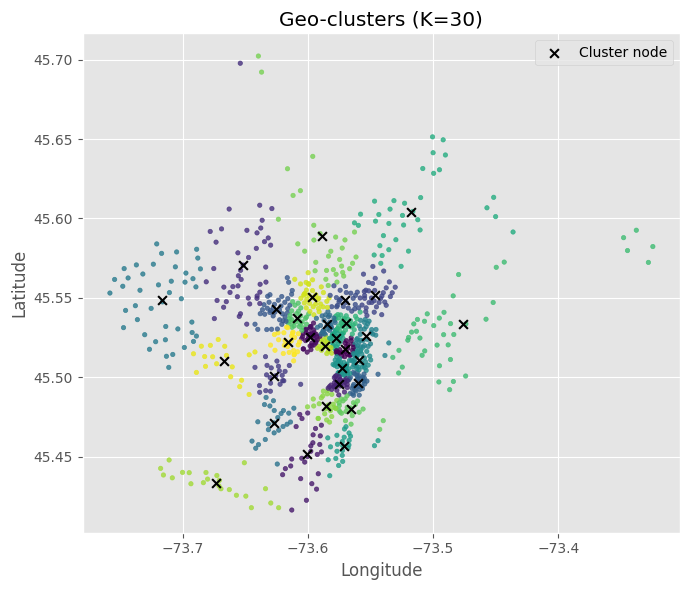

In [5]:
# --- Build station_features and run KMeans clustering ---

df_m = df_month.copy()

# mark AM / PM peak trips (outward)
df_m["is_am_peak"] = (df_m["hour"] >= 6) & (df_m["hour"] < 10)
df_m["is_pm_peak"] = (df_m["hour"] >= 16) & (df_m["hour"] < 20)

# aggregate by start station
grouped = df_m.groupby(start_name_col)

station_features = grouped.agg({
    start_lat_col: "median",
    start_lon_col: "median",
    start_name_col: "size",    # number of starts
    "is_am_peak": "sum",
    "is_pm_peak": "sum",
    "duration_min": "mean"
}).rename(columns={
    start_lat_col: "lat",
    start_lon_col: "lon",
    start_name_col: "starts",
    "is_am_peak": "am_starts",
    "is_pm_peak": "pm_starts",
    "duration_min": "avg_duration"
})

# add "ends" and net_flow
end_counts = df_m.groupby(end_name_col).size()
station_features["ends"] = end_counts.reindex(station_features.index).fillna(0)
station_features["net_flow"] = station_features["ends"] - station_features["starts"]

station_features.index.name = "station"

# drop weird coordinates
station_features["lat"] = station_features["lat"].replace(0, np.nan)
station_features["lon"] = station_features["lon"].replace(0, np.nan)
station_features = station_features.dropna(subset=["lat", "lon"])

station_features = station_features[
    (station_features["lat"] >= 40) & (station_features["lat"] <= 50) &
    (station_features["lon"] >= -80) & (station_features["lon"] <= -60)
].copy()

print("Number of stations:", len(station_features))

# KMeans on lat / lon (weighted by starts)
coords = station_features[["lat", "lon"]].values
weights = station_features["starts"].values

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(coords, sample_weight=weights)

station_features["geo_cluster"] = kmeans.labels_

print("\nStations per cluster:")
print(station_features["geo_cluster"].value_counts().sort_index())

# simple central point (node) per cluster
cluster_nodes = []

for c in sorted(station_features["geo_cluster"].unique()):
    sub = station_features[station_features["geo_cluster"] == c]
    node_lat = sub["lat"].mean()
    node_lon = sub["lon"].mean()

    dist_deg = np.sqrt((sub["lat"] - node_lat) ** 2 + (sub["lon"] - node_lon) ** 2)
    avg_dist_deg = dist_deg.mean()
    approx_radius_km = avg_dist_deg * 100.0  # very rough

    cluster_nodes.append({
        "geo_cluster": c,
        "node_lat": node_lat,
        "node_lon": node_lon,
        "approx_radius_km": approx_radius_km
    })

cluster_nodes_df = pd.DataFrame(cluster_nodes).sort_values("geo_cluster")
print("\nCluster nodes (first few):")
display(cluster_nodes_df.head())

# quick map: stations coloured by cluster, nodes in black
plt.figure(figsize=(7, 6))
plt.scatter(
    station_features["lon"],
    station_features["lat"],
    c=station_features["geo_cluster"],
    s=10,
    alpha=0.8
)
plt.scatter(
    cluster_nodes_df["node_lon"],
    cluster_nodes_df["node_lat"],
    c="black",
    s=40,
    marker="x",
    label="Cluster node"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Geo-clusters (K={N_CLUSTERS})")
plt.legend()
plt.tight_layout()
plt.show()


# Attach geo_cluster to trips + build 3D demand

Here we move from station-level to cluster-level demand:

* Merge the geo_cluster labels back onto the monthly trips, using the start station as the key.

* Split trips into AM and PM peak windows and count how many trips start in each cluster on each date.

* Reindex so that all clusters and all dates are represented, filling missing counts with zero.

* Stack the AM and PM matrices into a 3D array demand_3d_month[t, c, p] and print total AM, PM, and combined outward demand across the month.

In [6]:
# --- Attach geo_cluster to trips and build demand_3d_month ---

# station -> cluster mapping
station_features_for_merge = station_features[["geo_cluster"]].copy()
station_features_for_merge.index = station_features_for_merge.index.astype(str)

df_month_cl = df_month.copy()
df_month_cl[start_name_col] = df_month_cl[start_name_col].astype(str)

df_month_cl = df_month_cl.merge(
    station_features_for_merge,
    left_on=start_name_col,
    right_index=True,
    how="left"
)

print("Rows after merge with geo_cluster:", len(df_month_cl))
print("Rows with missing cluster:", df_month_cl["geo_cluster"].isna().sum())

# keep only trips with a mapped cluster
df_month_cl = df_month_cl[~df_month_cl["geo_cluster"].isna()].copy()
df_month_cl["geo_cluster"] = df_month_cl["geo_cluster"].astype(int)

# AM / PM outward peak demand
is_am_peak = (df_month_cl["hour"] >= 6) & (df_month_cl["hour"] < 10)
is_pm_peak = (df_month_cl["hour"] >= 16) & (df_month_cl["hour"] < 20)

df_am = df_month_cl[is_am_peak][["date", "geo_cluster"]]
df_pm = df_month_cl[is_pm_peak][["date", "geo_cluster"]]

# list of clusters
all_clusters = sorted(station_features["geo_cluster"].unique())
clusters_month = all_clusters

# daily demand per cluster
cluster_daily_am = (
    df_am.groupby(["date", "geo_cluster"]).size().unstack(fill_value=0)
)
cluster_daily_pm = (
    df_pm.groupby(["date", "geo_cluster"]).size().unstack(fill_value=0)
)

# reindex to all clusters (fill missing with 0)
cluster_daily_am = cluster_daily_am.reindex(columns=all_clusters, fill_value=0)
cluster_daily_pm = cluster_daily_pm.reindex(columns=all_clusters, fill_value=0)

# align dates
all_dates = sorted(set(cluster_daily_am.index) | set(cluster_daily_pm.index))
cluster_daily_am = cluster_daily_am.reindex(index=all_dates, fill_value=0)
cluster_daily_pm = cluster_daily_pm.reindex(index=all_dates, fill_value=0)

dates_month = np.array(all_dates)

# tensor: demand_3d_month[t, c, p]   p=0 AM, p=1 PM
demand_am = cluster_daily_am.values
demand_pm = cluster_daily_pm.values
demand_3d_month = np.stack([demand_am, demand_pm], axis=2)

TOTAL_DEMAND_AM  = demand_am.sum()
TOTAL_DEMAND_PM  = demand_pm.sum()
TOTAL_DEMAND_ALL = demand_3d_month.sum()

print("\nDays in model:", len(dates_month))
print("Number of geo-clusters:", len(all_clusters))
print("Total OUTWARD AM trips (peak):", int(TOTAL_DEMAND_AM))
print("Total OUTWARD PM trips (peak):", int(TOTAL_DEMAND_PM))
print("Total OUTWARD AM+PM trips (peak):", int(TOTAL_DEMAND_ALL))


Rows after merge with geo_cluster: 851645
Rows with missing cluster: 0

Days in model: 30
Number of geo-clusters: 30
Total OUTWARD AM trips (peak): 142538
Total OUTWARD PM trips (peak): 263253
Total OUTWARD AM+PM trips (peak): 405791


# Phase 1 optimization model (weekday vs weekend bikes)

This cell sets up and solves the Phase 1 optimization model:

* Build sets for days, clusters, periods, and define which days are weekdays vs weekends.

* Create decision variables for the number of bikes allocated per cluster and day-type, plus shortage variables per day/cluster/period.

* Add constraints so that shortages are limited by the TAU_CLUSTER tolerance and so total bikes across clusters match the system total.

* Minimize overall shortage, solve the model, and then compute the optimal bikes per cluster for weekday and weekend, along with the average bikes per cluster over the month and the shortage rate.

In [7]:
# --- Weekday vs weekend optimization on outward demand ---

num_days_m, num_clusters_m, num_periods = demand_3d_month.shape
T = range(num_days_m)
C = range(num_clusters_m)
P = range(num_periods)

dates_dt = pd.to_datetime(dates_month)

# 0 = weekday, 1 = weekend
D = range(2)
daytype_labels = ["Weekday", "Weekend"]

# mark each day as weekday / weekend
day_type_of_t = {}
for t in T:
    wd = dates_dt[t].weekday()     # Mon=0 .. Sun=6
    if wd >= 5:
        day_type_of_t[t] = 1
    else:
        day_type_of_t[t] = 0

# how many days of each type
days_per_type = np.zeros(2, dtype=int)
for t in T:
    d = day_type_of_t[t]
    days_per_type[d] += 1

# build model
m = gp.Model("BIXI_phase1")

# B[d,c]: bikes in cluster c on day-type d
B = m.addVars(D, C, vtype=GRB.INTEGER, name="B")

# s[t,c,p]: shortage (unmet demand)
s = m.addVars(T, C, P, vtype=GRB.CONTINUOUS, lb=0.0, name="shortage")

# 1) total bikes per day-type = TOTAL_BIKES
for d in D:
    m.addConstr(sum(B[d, c] for c in C) == TOTAL_BIKES)

# 2) definition of shortage
for t in T:
    d = day_type_of_t[t]
    for c in C:
        for p in P:
            m.addConstr(
                s[t, c, p] >= demand_3d_month[t, c, p] - B[d, c]
            )

# 3) fairness cap per cluster
for c in C:
    demand_c = float(demand_3d_month[:, c, :].sum())
    if demand_c > 0:
        m.addConstr(
            sum(s[t, c, p] for t in T for p in P) <= TAU_CLUSTER * demand_c
        )

# objective: minimise total shortage
m.setObjective(
    sum(s[t, c, p] for t in T for c in C for p in P),
    GRB.MINIMIZE
)

m.Params.OutputFlag = 1
m.optimize()

if m.status == GRB.OPTIMAL:
    # bikes per day-type & cluster
    B_type = np.zeros((2, num_clusters_m), dtype=float)
    for d in D:
        for c in C:
            B_type[d, c] = B[d, c].X

    # average bikes per cluster over the month
    avg_bikes_cluster = np.zeros(num_clusters_m, dtype=float)
    for c in C:
        avg_bikes_cluster[c] = (
            B_type[0, c] * days_per_type[0] +
            B_type[1, c] * days_per_type[1]
        ) / num_days_m

    total_bikes_avg = avg_bikes_cluster.sum()
    total_shortage = sum(s[t, c, p].X for t in T for c in C for p in P)
    if TOTAL_DEMAND_ALL > 0:
        shortage_rate = total_shortage / TOTAL_DEMAND_ALL
    else:
        shortage_rate = 0.0

    # cluster ids for later tables/plots
    clusters_month = list(range(num_clusters_m))

    cluster_result = pd.DataFrame({
        "geo_cluster": clusters_month,
        "opt_bikes_cluster": avg_bikes_cluster,
        "AM_outward_demand_total": demand_3d_month[:, :, 0].sum(axis=0),
        "PM_outward_demand_total": demand_3d_month[:, :, 1].sum(axis=0),
    }).sort_values("geo_cluster")
    display(cluster_result)

    print("Average bikes in system:", round(total_bikes_avg, 1))
    print("Total shortage (trips):", round(total_shortage, 1))
    print("Shortage rate (%):", round(shortage_rate * 100, 2))
else:
    print("Model not optimal. Status =", m.status)


Restricted license - for non-production use only - expires 2027-11-29
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1832 rows, 1860 columns and 5460 nonzeros (Min)
Model fingerprint: 0x416b67b1
Model has 1800 linear objective coefficients
Variable types: 1800 continuous, 60 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+04]
Presolve removed 210 rows and 210 columns
Presolve time: 0.02s
Presolved: 1622 rows, 1650 columns, 4830 nonzeros
Variable types: 1590 continuous, 60 integer (0 binary)

Root relaxation: objective 3.694112e+04, 504 iterations, 0.02 seconds (0.01 work units)

    Nodes    |    Current Node    |     O

,geo_cluster,opt_bikes_cluster,AM_outward_demand_total,PM_outward_demand_total
0,0,582.7,9830,16359
1,1,593.7,8141,17476
2,2,120.9,1982,2623
3,3,530.9,6686,16320
4,4,125.1,1877,3363
5,5,149.6,1857,4307
6,6,385.9,5897,9482
7,7,303.6,5777,6743
8,8,359.8,5226,7854
9,9,460.9,6625,13919


Average bikes in system: 10000.0
Total shortage (trips): 36942.0
Shortage rate (%): 9.1


# PHASE 1 – DIAGNOSTICS + GRAPHS

In this cell we analyze and visualize the Phase 1 solution:

* Build a cluster-level table showing optimal bikes, total demand, shortage, and shortage rate for each geo-cluster.

* Plot the top clusters by shortage rate to see where the system is under-served.

* Create a daily performance table (demand vs shortage, weekdays vs weekends, AM vs PM) and plot how daily demand and shortages evolve over time.

* Finally, compare average daily demand (weekday/weekend) with the bike allocation per cluster to understand how well the inventory matches the patterns.


=== 1) Cluster-level performance ===


,geo_cluster,bikes_weekday,bikes_weekend,avg_bikes,total_demand,shortage,served,shortage_rate_%
0,0,559.0,638.0,582.7,26189,2018.0,24171.0,7.705525
1,1,588.0,607.0,593.7,25617,3001.0,22616.0,11.714877
2,2,126.0,109.0,120.9,4605,485.0,4120.0,10.532030
3,3,533.0,526.0,530.9,23006,2818.0,20188.0,12.248979
4,4,132.0,109.0,125.1,5240,630.0,4610.0,12.022901
5,5,137.0,179.0,149.6,6164,1151.0,5013.0,18.672940
6,6,400.0,353.0,385.9,15379,1226.0,14153.0,7.971910
7,7,324.0,256.0,303.6,12520,702.0,11818.0,5.607029
8,8,367.0,343.0,359.8,13080,1093.0,11987.0,8.356269
9,9,478.0,421.0,460.9,20544,2520.0,18024.0,12.266355


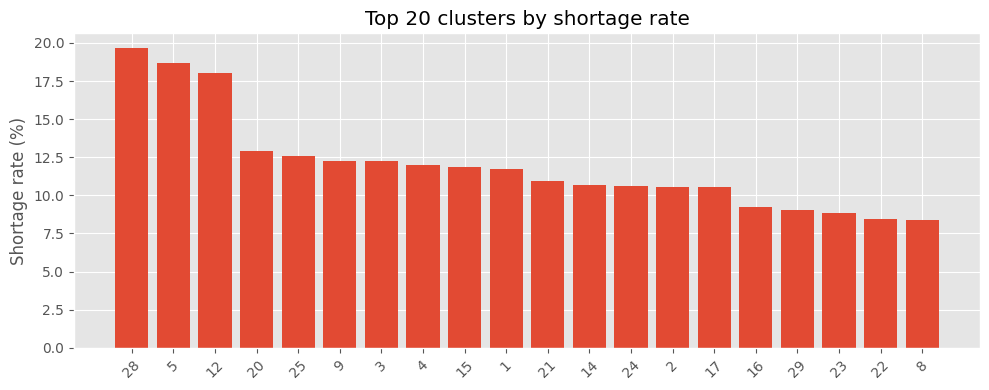


=== 2) Weekday vs Weekend summary ===


,day_type,num_days,total_demand,total_shortage,shortage_rate_%,system_bikes
0,Weekday,21,326121,36882.0,11.309299,10000.0
1,Weekend,9,79670,60.0,0.075311,10000.0


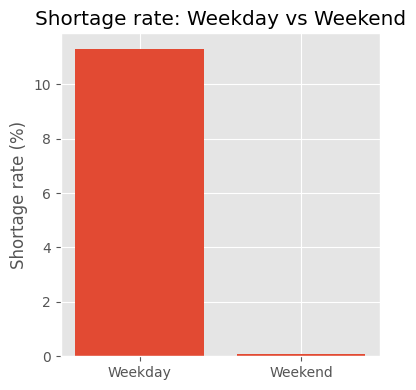


=== 3) Daily performance ===


,date,weekday,day_type,demand,shortage,shortage_rate_%,shortage_AM,shortage_PM
0,2024-11-01,Fri,Weekday,24810,6284.0,25.328497,421.0,5863.0
1,2024-11-02,Sat,Weekend,13943,29.0,0.207990,0.0,29.0
2,2024-11-03,Sun,Weekend,10671,2.0,0.018742,0.0,2.0
3,2024-11-04,Mon,Weekday,14393,28.0,0.194539,28.0,0.0
4,2024-11-05,Tue,Weekday,24221,5502.0,22.715825,336.0,5166.0
5,2024-11-06,Wed,Weekday,26783,7957.0,29.709144,697.0,7260.0
6,2024-11-07,Thu,Weekday,24152,5840.0,24.180192,133.0,5707.0
7,2024-11-08,Fri,Weekday,19545,2511.0,12.847276,6.0,2505.0
8,2024-11-09,Sat,Weekend,12759,29.0,0.227291,0.0,29.0
9,2024-11-10,Sun,Weekend,10375,0.0,0.000000,0.0,0.0


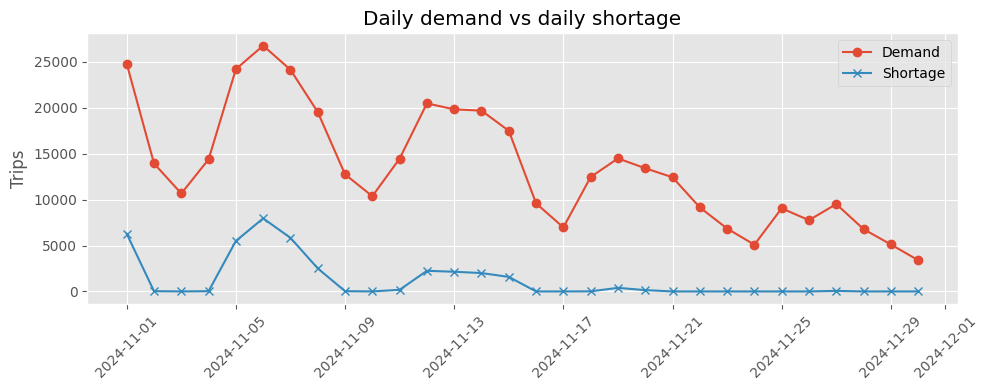

DataFrame with average daily AM+PM demand and bike allocation per cluster:


,geo_cluster,bikes_weekday,bikes_weekend,avg_daily_demand_weekday,avg_daily_demand_weekend
0,0,559.0,638.0,994.761905,588.777778
1,1,588.0,607.0,982.571429,553.666667
2,2,126.0,109.0,180.333333,90.888889
3,3,533.0,526.0,882.380952,497.333333
4,4,132.0,109.0,208.619048,95.444444
5,5,137.0,179.0,236.571429,132.888889
6,6,400.0,353.0,592.571429,326.111111
7,7,324.0,256.0,482.047619,266.333333
8,8,367.0,343.0,502.952381,279.777778
9,9,478.0,421.0,809.714286,393.333333


In [8]:
# ============================================================
#            PHASE 1 – DIAGNOSTICS + GRAPHS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Basic sets
num_days, num_clusters, num_periods = demand_3d_month.shape
T = range(num_days)
C = range(num_clusters)
P = range(num_periods)

dates_dt = pd.to_datetime(dates_month)

# Day-type labels
daytype_labels = ["Weekday", "Weekend"]

# Determine weekday/weekend for each day
day_type_of_t = {}
for t in T:
    wd = dates_dt[t].weekday()       # Mon=0..Sun=6
    day_type_of_t[t] = 1 if wd >= 5 else 0

# Count days per type
days_per_type = np.zeros(2, dtype=int)
for t in T:
    days_per_type[day_type_of_t[t]] += 1


# ============================================================
# 1) CLUSTER-LEVEL TABLE
# ============================================================

# Total outward demand per cluster
total_demand_cluster = demand_3d_month.sum(axis=(0, 2))

# Total shortage per cluster (sum over all days + AM/PM)
shortage_cluster = np.zeros(num_clusters)
for c in C:
    shortage_cluster[c] = sum(s[t, c, p].X for t in T for p in P)

# Average bikes per cluster over month
avg_bikes_cluster = np.zeros(num_clusters)
for c in C:
    avg_bikes_cluster[c] = (
        B_type[0, c] * days_per_type[0] +
        B_type[1, c] * days_per_type[1]
    ) / num_days

cluster_perf_df = pd.DataFrame({
    "geo_cluster": clusters_month,
    "bikes_weekday": B_type[0, :],
    "bikes_weekend": B_type[1, :],
    "avg_bikes": avg_bikes_cluster,
    "total_demand": total_demand_cluster,
    "shortage": shortage_cluster
})

cluster_perf_df["served"] = (
    cluster_perf_df["total_demand"] - cluster_perf_df["shortage"]
)
cluster_perf_df["shortage_rate_%"] = np.where(
    cluster_perf_df["total_demand"] > 0,
    100 * cluster_perf_df["shortage"] / cluster_perf_df["total_demand"],
    0.0
)

cluster_perf_df = cluster_perf_df.sort_values("geo_cluster").reset_index(drop=True)

print("\n=== 1) Cluster-level performance ===")
display(cluster_perf_df.head(15))   # show first 15 clusters


# ======== Graph: Top 20 clusters by shortage rate ========

sorted_short = cluster_perf_df.sort_values("shortage_rate_%", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(
    sorted_short["geo_cluster"].astype(str).iloc[:20],
    sorted_short["shortage_rate_%"].iloc[:20]
)
plt.xticks(rotation=45)
plt.ylabel("Shortage rate (%)")
plt.title("Top 20 clusters by shortage rate")
plt.tight_layout()
plt.show()


# ============================================================
# 2) WEEKDAY vs WEEKEND SUMMARY
# ============================================================

rows = []
for d in [0, 1]:  # 0 = weekday, 1 = weekend
    days_d = [t for t in T if day_type_of_t[t] == d]
    demand_d = demand_3d_month[days_d, :, :].sum()
    shortage_d = sum(s[t, c, p].X for t in days_d for c in C for p in P)

    rows.append({
        "day_type": daytype_labels[d],
        "num_days": len(days_d),
        "total_demand": demand_d,
        "total_shortage": shortage_d,
        "shortage_rate_%": 100 * shortage_d / demand_d if demand_d > 0 else 0.0,
        "system_bikes": B_type[d, :].sum()
    })

weekday_weekend_df = pd.DataFrame(rows)

print("\n=== 2) Weekday vs Weekend summary ===")
display(weekday_weekend_df)


# ======== Graph: Shortage by day-type ========

plt.figure(figsize=(4, 4))
plt.bar(
    weekday_weekend_df["day_type"],
    weekday_weekend_df["shortage_rate_%"]
)
plt.ylabel("Shortage rate (%)")
plt.title("Shortage rate: Weekday vs Weekend")
plt.tight_layout()
plt.show()


# ============================================================
# 3) DAILY PERFORMANCE
# ============================================================

daily_rows = []
for t in T:
    demand_t = demand_3d_month[t, :, :].sum()
    shortage_t = sum(s[t, c, p].X for c in C for p in P)

    daily_rows.append({
        "date": dates_dt[t].date(),
        "weekday": dates_dt[t].strftime("%a"),
        "day_type": daytype_labels[day_type_of_t[t]],
        "demand": demand_t,
        "shortage": shortage_t,
        "shortage_rate_%": 100 * shortage_t / demand_t if demand_t > 0 else 0.0,
        "shortage_AM": sum(s[t, c, 0].X for c in C),
        "shortage_PM": sum(s[t, c, 1].X for c in C),
    })

daily_perf_df = pd.DataFrame(daily_rows).sort_values("date")

print("\n=== 3) Daily performance ===")
display(daily_perf_df.head(10))


# ======== Graph: Daily demand vs shortage ========

plt.figure(figsize=(10, 4))
plt.plot(daily_perf_df["date"], daily_perf_df["demand"], marker="o")
plt.plot(daily_perf_df["date"], daily_perf_df["shortage"], marker="x")
plt.xticks(rotation=45)
plt.ylabel("Trips")
plt.title("Daily demand vs daily shortage")
plt.legend(["Demand", "Shortage"])
plt.tight_layout()
plt.show()




# ======== Graph: Daily demand vs shortage ========

num_days, num_clusters, num_periods = demand_3d_month.shape
T = range(num_days)
C = range(num_clusters)

# 1. Initialize arrays and counters
daily_demand_weekday = np.zeros(num_clusters)
daily_demand_weekend = np.zeros(num_clusters)
num_weekdays = 0
num_weekenddays = 0

# 2. Iterate through each day
for t in T:
    # 3. Determine if the current day is a Weekday or Weekend
    is_weekend = (day_type_of_t[t] == 1)

    # 4. Calculate total AM+PM demand for each cluster for day t
    daily_demand_t_c = demand_3d_month[t, :, 0] + demand_3d_month[t, :, 1]

    # 5. Add this total demand to the corresponding array and increment counter
    if not is_weekend:
        daily_demand_weekday += daily_demand_t_c
        num_weekdays += 1
    else:
        daily_demand_weekend += daily_demand_t_c
        num_weekenddays += 1

# 6. Calculate average daily demand
avg_daily_demand_weekday = (daily_demand_weekday / num_weekdays) if num_weekdays > 0 else np.zeros(num_clusters)
avg_daily_demand_weekend = (daily_demand_weekend / num_weekenddays) if num_weekenddays > 0 else np.zeros(num_clusters)

cluster_demand_bikes_df = pd.DataFrame({
    "geo_cluster": C,
    "bikes_weekday": B_type[0, :],
    "bikes_weekend": B_type[1, :],
    "avg_daily_demand_weekday": avg_daily_demand_weekday,
    "avg_daily_demand_weekend": avg_daily_demand_weekend
})

print("DataFrame with average daily AM+PM demand and bike allocation per cluster:")
display(cluster_demand_bikes_df)

# Choose snapshot day + filter trips (Phase 2 setup)

This cell prepares a single-day snapshot for the routing model:

* Pick one specific date and time window (e.g. 6:00–20:00) within the chosen month.

* Filter the monthly trips to only keep rides in that snapshot window.

* Count how many trips start in each geo-cluster during that window (outward trips), which will later drive surplus/deficit calculations for rebalancing.

In [9]:
import pandas as pd
import numpy as np

# pick one day and time window
snapshot_date = pd.Timestamp('2024-11-13').date() # Set snapshot date to November 13th
start_hour = 6
end_hour = 20   # 6 am to 8pm

df_snapshot = df_month_cl[
    (df_month_cl["date"].dt.date == snapshot_date) &
    (df_month_cl["hour"] >= start_hour) &
    (df_month_cl["hour"] < end_hour)
].copy()

print("Snapshot date:", snapshot_date)
print("Trips in this window:", len(df_snapshot))


# outward = trips starting in cluster
outward_trips = (
    df_snapshot
    .groupby("geo_cluster")
    .size()
    .rename("outward_trips"))



Snapshot date: 2024-11-13
Trips in this window: 30506


# Compute inward/outward flow + rebalancing limits

Here we build the cluster-level flow table for the snapshot:

* Map each trip’s end station to a geo-cluster and drop trips with missing cluster information.

* Count inward trips per cluster and combine them with the outward trips from the previous cell.

* Compute the net change per cluster and derive a shortage indicator and threshold based on the earlier optimization.

* From this, calculate lower and upper bounds on how many bikes can be picked up or dropped off in each cluster, and store everything in the bike_flow DataFrame.

In [10]:
# map end station → cluster
station_to_cluster = station_features["geo_cluster"].to_dict()
df_snapshot["end_geo_cluster"] = df_snapshot[end_name_col].map(station_to_cluster)

df_snapshot = df_snapshot[~df_snapshot["end_geo_cluster"].isna()].copy()
df_snapshot["end_geo_cluster"] = df_snapshot["end_geo_cluster"].astype(int)

inward_trips = (
        df_snapshot
        .groupby("end_geo_cluster")
        .size()
        .rename("inward_trips"))

# combine
bike_flow = pd.DataFrame({
    "outward_trips": outward_trips,
    "inward_trips": inward_trips
}).fillna(0)

# inward - outward
bike_flow["net_change"] = bike_flow["inward_trips"] - bike_flow["outward_trips"]

# small band so we don't chase every single bike
bike_flow["threshold"] = (bike_flow["net_change"].abs() * 0.05).round().astype(int)

bike_flow["has_shortage"] = (bike_flow["net_change"] < 0).astype(int)
bike_flow["has_surplus"]  = (bike_flow["net_change"] > 0).astype(int)

# pick-up (surplus clusters)
bike_flow["pickup_lower_limit"] = bike_flow["has_surplus"] * (
    bike_flow["net_change"] - bike_flow["threshold"])
bike_flow["pickup_upper_limit"] = bike_flow["has_surplus"] * (
    bike_flow["net_change"] + bike_flow["threshold"])

# drop-off (shortage clusters)
bike_flow["dropoff_lower_limit"] = bike_flow["has_shortage"] * (
    -bike_flow["net_change"] - bike_flow["threshold"])
bike_flow["dropoff_upper_limit"] = bike_flow["has_shortage"] * (
    -bike_flow["net_change"] + bike_flow["threshold"])

int_cols = [
    "outward_trips", "inward_trips", "net_change",
    "threshold", "pickup_lower_limit", "pickup_upper_limit",
    "dropoff_lower_limit", "dropoff_upper_limit"]
bike_flow[int_cols] = bike_flow[int_cols].astype(int)

print("\nCluster-level flow in snapshot:")
display(bike_flow)

print("\nTotal net_change (sum over clusters):", bike_flow["net_change"].sum())


Cluster-level flow in snapshot:


,outward_trips,inward_trips,net_change,threshold,has_shortage,has_surplus,pickup_lower_limit,pickup_upper_limit,dropoff_lower_limit,dropoff_upper_limit
0,1888,1697,-191,10,1,0,0,0,181,201
1,2050,1818,-232,12,1,0,0,0,220,244
2,426,413,-13,1,1,0,0,0,12,14
3,1617,1525,-92,5,1,0,0,0,87,97
4,456,479,23,1,0,1,22,24,0,0
5,599,495,-104,5,1,0,0,0,99,109
6,1175,1325,150,8,0,1,142,158,0,0
7,907,782,-125,6,1,0,0,0,119,131
8,1144,1103,-41,2,1,0,0,0,39,43
9,1559,2144,585,29,0,1,556,614,0,0



Total net_change (sum over clusters): -1


# Distance matrix + pick/drop bounds for routing

This cell sets up the spatial side and the bounds needed for Phase 2:

* Compute the average lat/lon per geo-cluster and build an index of cluster IDs and node indices.

* Define a helper function that approximates Manhattan distance (in km) between two clusters using their coordinates.

* Build a full distance matrix dist_km[i, j] for all ordered pairs of clusters.

* Extract the pick-up and drop-off bounds from bike_flow into simple Python lists so they can be used inside the Gurobi model.

In [11]:
import gurobipy as gp
from gurobipy import GRB
from math import radians, cos


# recall cluster coordinates and create ranges and lengths for iteration
cluster_coords = station_features.groupby("geo_cluster")[["lat", "lon"]].mean()
cluster_ids = list(bike_flow.index)
n_nodes = len(cluster_ids)
nodes = list(range(n_nodes))

#function for turning two sets of coordinates into a distance between cluster-pairs
def manhattan_km(lat1, lon1, lat2, lon2):
    #formulas for converting coordinate differences into km
    avg_lat_rad = radians((lat1 + lat2) / 2)
    lat_to_km = 111.0
    lon_to_km = 111.0 * cos(avg_lat_rad)
    #Add the length of two lines at a right angle
    return abs(lat1 - lat2) * lat_to_km + abs(lon1 - lon2) * lon_to_km

#Create a matrix with the Manhattan distances between each cluster-pair
dist_km = np.zeros((n_nodes, n_nodes))
for i in nodes:
    for j in nodes:
        cid_i = cluster_ids[i]
        cid_j = cluster_ids[j]
        lat1, lon1 = cluster_coords.loc[cid_i, ["lat", "lon"]]
        lat2, lon2 = cluster_coords.loc[cid_j, ["lat", "lon"]]
        dist_km[i, j] = manhattan_km(lat1, lon1, lat2, lon2)

# limits from bike_flow
pickup_lb  = bike_flow.loc[cluster_ids, "pickup_lower_limit"].tolist()
pickup_ub  = bike_flow.loc[cluster_ids, "pickup_upper_limit"].tolist()
dropoff_lb = bike_flow.loc[cluster_ids, "dropoff_lower_limit"].tolist()
dropoff_ub = bike_flow.loc[cluster_ids, "dropoff_upper_limit"].tolist()




# Build Phase 2 truck routing + rebalancing model

In this cell we formulate the combined routing and rebalancing model:

* Create decision variables for the truck route (x[i,j]), number of bikes picked up and dropped off in each cluster (p[i], d[i]), and flow of bikes on each arc (f[i,j]), plus helper variables for subtour elimination (u[i]).

* Set the objective to minimize the total distance travelled by the truck based on the distance matrix.

* Add constraints for pick-up and drop-off limits per cluster, flow conservation through the truck, and a simple capacity constraint tying f[i,j] to x[i,j].

(The remaining constraints ensure the route structure is feasible and consistent with the snapshot imbalances.)

In [12]:
m = gp.Model("route")

#DECISION VARIABLES

x = m.addVars(nodes, nodes, vtype=GRB.BINARY, name="x") #whether a trip is made from i to j
p = m.addVars(nodes, vtype=GRB.CONTINUOUS, lb=0, name="p") #number of pickups at cluster i
d = m.addVars(nodes, vtype=GRB.CONTINUOUS, lb=0, name="d") #number of dropoffs at cluster i
f = m.addVars(nodes, nodes, vtype=GRB.CONTINUOUS, lb=0, name="f") #number of bikes in truck from i to j
u = m.addVars(nodes, vtype=GRB.CONTINUOUS, lb=0, name="u") #used for subtour elimination

# distance objective
m.setObjective(
    gp.quicksum(dist_km[i, j] * x[i, j] for i in nodes for j in nodes if i != j),
    GRB.MINIMIZE)

#CONSTRAINTS

# in = 1, out = 1
m.addConstrs(
    (gp.quicksum(x[j, i] for j in nodes if j != i) == 1 for i in nodes),
    name="in_deg")
m.addConstrs(
    (gp.quicksum(x[i, j] for j in nodes if j != i) == 1 for i in nodes),
    name="out_deg")

# MTZ (cluster 0 is pseudo-depot)
big_M = 1000
non_depot = [i for i in nodes if i != 0]
m.addConstrs(
    (u[i] - u[j] + big_M * x[i, j] <= big_M - 1 for i in non_depot for j in non_depot if i != j),
    name="mtz")
m.addConstrs((u[i] >= 1 for i in non_depot), name="u_lb")
m.addConstrs((u[i] <= big_M - 1 for i in non_depot), name="u_ub")

# pick / drop bounds
m.addConstrs((p[i] >= pickup_lb[i]  for i in nodes), name="p_lb")
m.addConstrs((p[i] <= pickup_ub[i]  for i in nodes), name="p_ub")
m.addConstrs((d[i] >= dropoff_lb[i] for i in nodes), name="d_lb")
m.addConstrs((d[i] <= dropoff_ub[i] for i in nodes), name="d_ub")

# simple flow conservation
TRUCK_CAP = 1000

m.addConstrs(
    (sum(f[j, i] for j in nodes if j != i) + p[i] - d[i]
      == sum(f[i, j] for j in nodes if j != i)
      for i in nodes),
    name="flow")

m.addConstrs(
    (f[i, j] <= TRUCK_CAP * x[i, j] for i in nodes for j in nodes),
        name="capacity")


{(0, 0): <gurobi.Constr *Awaiting Model Update*>,
 (0, 1): <gurobi.Constr *Awaiting Model Update*>,
 (0, 2): <gurobi.Constr *Awaiting Model Update*>,
 (0, 3): <gurobi.Constr *Awaiting Model Update*>,
 (0, 4): <gurobi.Constr *Awaiting Model Update*>,
 (0, 5): <gurobi.Constr *Awaiting Model Update*>,
 (0, 6): <gurobi.Constr *Awaiting Model Update*>,
 (0, 7): <gurobi.Constr *Awaiting Model Update*>,
 (0, 8): <gurobi.Constr *Awaiting Model Update*>,
 (0, 9): <gurobi.Constr *Awaiting Model Update*>,
 (0, 10): <gurobi.Constr *Awaiting Model Update*>,
 (0, 11): <gurobi.Constr *Awaiting Model Update*>,
 (0, 12): <gurobi.Constr *Awaiting Model Update*>,
 (0, 13): <gurobi.Constr *Awaiting Model Update*>,
 (0, 14): <gurobi.Constr *Awaiting Model Update*>,
 (0, 15): <gurobi.Constr *Awaiting Model Update*>,
 (0, 16): <gurobi.Constr *Awaiting Model Update*>,
 (0, 17): <gurobi.Constr *Awaiting Model Update*>,
 (0, 18): <gurobi.Constr *Awaiting Model Update*>,
 (0, 19): <gurobi.Constr *Awaiting Model 

# Solve Phase 2 model and report distance

This short cell runs the solver and reports the result:

* Call m.optimize() to solve the truck routing and rebalancing model.

* Print the optimized total distance (in km) that the truck needs to travel to execute the rebalancing plan

In [13]:
m.optimize()
print(f'\nThe optimized distance for the reallocation operation is {round(m.objVal,2)} km')

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1980 rows, 1890 columns and 7954 nonzeros (Min)
Model fingerprint: 0x69732641
Model has 870 linear objective coefficients
Variable types: 990 continuous, 900 integer (900 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 3e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]
Presolve removed 208 rows and 95 columns
Presolve time: 0.05s
Presolved: 1772 rows, 1795 columns, 15377 nonzeros
Variable types: 925 continuous, 870 integer (870 binary)
Found heuristic solution: objective 253.0446372

Root relaxation: objective 1.064797e+02, 1648 iterations, 0.05 seconds (0.05 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  D

# Reconstruct truck tour + summarize impact

The final cell decodes and visualizes the Phase 2 solution:

* Read the x[i,j] variables to rebuild the sequence of clusters visited by the truck and store the tour in a list.

* Build a DataFrame summarizing, for each cluster, outward trips, inward trips, net change, and the optimized pick-up and drop-off quantities from the model.

* Compute the new net change after the truck moves bikes and compare it to the original net change.

* Plot a bar chart for the clusters with the largest imbalances, showing net change before vs after rebalancing to highlight how the truck route helps smooth things out.

Truck tour (geo_cluster):
0→14 | 14→26 | 26→1 | 1→29 | 29→21 | 21→8 | 8→4 | 4→12 | 12→28 | 28→5 | 5→11 | 11→25 | 25→2 | 2→16 | 16→22 | 22→24 | 24→3 | 3→9 | 9→15 | 15→17 | 17→10 | 10→19 | 19→7 | 7→6 | 6→27 | 27→23 | 23→18 | 18→20 | 20→13 | 13→0

Rebalancing plan in snapshot:


,geo_cluster,outward_trips,inward_trips,net_change,pickup_plan,dropoff_plan
0,0,1888,1697,-191,0.0,201.0
1,1,2050,1818,-232,0.0,220.0
2,2,426,413,-13,0.0,12.0
3,3,1617,1525,-92,0.0,87.0
4,4,456,479,23,24.0,0.0
5,5,599,495,-104,0.0,99.0
6,6,1175,1325,150,142.0,0.0
7,7,907,782,-125,0.0,119.0
8,8,1144,1103,-41,0.0,39.0
9,9,1559,2144,585,556.0,0.0


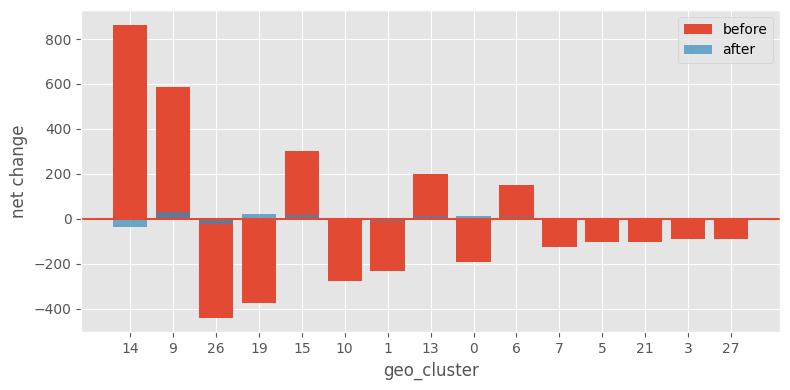

In [14]:
import matplotlib.pyplot as plt

cluster_ids = list(bike_flow.index)
n_nodes = len(cluster_ids)
nodes = list(range(n_nodes))

# Build an ordered sequence of trips
trips = []
for i in nodes:
    for j in nodes:
        if i != j and x[i, j].X == 1:
            trips.append((i, j))
tour = []
tracker = []
current = 0
while True:
    nxt = [j for (i, j) in trips if i == current]
    if not nxt:
        break
    j = nxt[0]
    tour.append((current, j))
    current = j
    if current == 0 or current in tracker:
        break
    tracker.append(current)

print("Truck tour (geo_cluster):")
print(" | ".join(f"{i}→{j}" for i, j in tour))

rows = []
for i in nodes:
    rows.append({
        "geo_cluster": i,
        "outward_trips": bike_flow.loc[i, "outward_trips"],
        "inward_trips": bike_flow.loc[i, "inward_trips"],
        "net_change": bike_flow.loc[i, "net_change"],
        "pickup_plan": p[i].X,
        "dropoff_plan": d[i].X
    })

plan_df = pd.DataFrame(rows).sort_values("geo_cluster").reset_index(drop=True)

print("\nRebalancing plan in snapshot:")
display(plan_df)

plan_df["net_after_truck"] = (
    plan_df["net_change"] - plan_df["pickup_plan"] + plan_df["dropoff_plan"])

top = plan_df.reindex(
    plan_df["net_change"].abs().sort_values(ascending=False).index[:15])

plt.figure(figsize=(8, 4))
plt.bar(top["geo_cluster"].astype(str), top["net_change"], label="before")
plt.bar(top["geo_cluster"].astype(str), top["net_after_truck"], alpha=0.7, label="after")
plt.axhline(0)
plt.legend()
plt.xlabel("geo_cluster")
plt.ylabel("net change")
plt.tight_layout()
plt.show()